In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from matplotlib.ticker import FormatStrFormatter
import os

In [6]:
os.chdir('/Users/tergemina/Library/CloudStorage/Dropbox/Ionome_GWAS/1001/github/Supplementary/FigS6/FigS6a/')

In [7]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

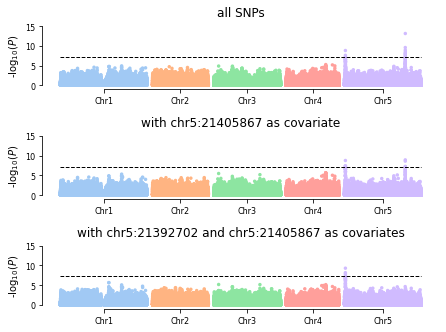

In [10]:
def covariate(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)

def plotting(dataframe,idx,text):
    sns.scatterplot(x='position',
                    y='P',
                    data=dataframe,
                    hue='chr',
                    palette='pastel',
                    marker='o',
                    s=12,
                    linewidth=0,
                    legend=False,
                    ax=ax[idx])
    ax[idx].set_xticks([chr1,chr2,chr3,chr4,chr5]),
    ax[idx].tick_params(axis='both', which='major', labelsize=8)
    ax[idx].set_xticklabels(["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
    ax[idx].set_title(text)
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
    ax[idx].hlines(y=-np.log10(0.05/len(classic)),
                 xmin=min(classic['position']),
                 xmax=max(classic['position']),
                 color='0',
                 linestyle='--',
                 linewidth=1,
                 zorder=1)
    ax[idx].set_ylim(-1,16)

cm = 1/2.54
fig , ax = plt.subplots(3,1,figsize=(16*cm,12*cm))

classic=covariate('690_Mg_blues.assoc.txt.gz')
plotting(classic,0,'all SNPs')

Chr5_21392702=covariate('690_Mg_blues_Chr5_21405867.assoc.txt.gz')
plotting(Chr5_21392702,1, 'with chr5:21405867 as covariate')

Chr5_21392702_21390834=covariate('690_Mg_blues_Chr5_21405867_21392702.assoc.txt.gz')
plotting(Chr5_21392702_21390834,2, 'with chr5:21392702 and chr5:21405867 as covariates')

sns.despine(trim=True)
plt.tight_layout()
# plt.savefig("FigS5a.pdf", format="pdf",bbox_inches="tight")
plt.savefig("FigS6a.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)

In [6]:
Chr5_21392702[Chr5_21392702['P'] > -np.log10(0.05/len(classic))]

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
529594,5,5:271816,271816,59,T,G,0.245,92.57941,16.35213,1.814120,1.829666,2.034395e-08,1.905488e-08,3.391859e-08,7.719994,-7.719994,100442662
529595,5,5:271817,271817,61,T,A,0.243,93.68839,16.37455,1.829161,1.844958,1.449886e-08,1.356444e-08,2.474524e-08,7.867598,-7.867598,100442663
529625,5,5:273701,273701,64,C,T,0.211,94.68325,17.31024,1.732245,1.746421,5.886263e-08,5.628658e-08,9.437396e-08,7.249595,-7.249595,100444547
529706,5,5:276733,276733,59,T,C,0.207,97.39382,17.35472,1.777554,1.792664,2.686721e-08,2.528409e-08,4.421026e-08,7.597153,-7.597153,100447579
529728,5,5:277765,277765,68,A,G,0.246,100.41820,16.18224,1.826663,1.842602,8.416562e-10,7.786247e-10,1.760168e-09,9.108672,-9.108672,100448611
529753,5,5:282011,282011,68,C,T,0.184,119.28680,17.79383,1.658238,1.671682,3.641165e-11,3.528039e-11,1.093886e-10,10.452467,-10.452467,100452857
529758,5,5:282729,282729,49,A,G,0.178,115.55090,17.99905,1.678417,1.692090,2.236866e-10,2.152087e-10,5.603915e-10,9.667140,-9.667140,100453575
529832,5,5:290125,290125,45,A,G,0.079,140.61770,25.20014,1.588155,1.603613,3.208833e-08,3.417060e-08,6.455795e-08,7.466347,-7.466347,100460971
529854,5,5:294236,294236,41,C,A,0.075,140.59400,25.55762,1.614936,1.630581,4.960994e-08,5.140352e-08,9.240761e-08,7.289007,-7.289007,100465082
529868,5,5:296588,296588,46,G,A,0.075,143.82260,25.85273,1.641134,1.656888,3.523767e-08,3.557936e-08,6.413880e-08,7.448802,-7.448802,100467434
